# Apophis non-Gaussian cut-plane inspection

This notebook scans the cached Apophis (`2004 MN4`) variant states, runs the same Henze–Zirkler normality test used by the tube generator, and visualizes rejected cut planes. It deliberately stops before constructing polygon boundaries.

In [1]:
from pathlib import Path
import json, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg

# Work whether Jupyter starts in the repository root or revision/.
start = Path.cwd().resolve()
REPO_ROOT = next((p for p in [start, *start.parents] if (p / 'src' / '.project-root').exists()), None)
if REPO_ROOT is None:
    raise RuntimeError('Could not find the NEOviz repository root.')
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from density_tube_generation.pipeline import (
    intersect_variants_with_plane, load_cutplanes, project_to_plane_2d,
)
import tube_generation.util as tube_util

TUBE_JSON = REPO_ROOT / 'data' / 'B612_data' / 'Test' / '2004 MN4' / 'tube_2004_MN4.json'
STATE_CACHE = REPO_ROOT / 'revision' / 'cache' / '2004_MN4_cutplane_states.npz'
ALPHA = 0.05
print('Repository:', REPO_ROOT)
print('Tube JSON exists:', TUBE_JSON.exists())
print('State cache exists:', STATE_CACHE.exists())

Repository: /mnt/c/Users/flan/Documents/NEOviz/NEOviz_repo
Tube JSON exists: True
State cache exists: True


## Load and validate the cached cut-plane states

The cache avoids re-reading hundreds of SPICE kernels. Each row corresponds to a tube cut plane.

In [2]:
if not STATE_CACHE.exists():
    raise FileNotFoundError(f'{STATE_CACHE} is missing; run revision/save_cutplane_states.py')
cutplanes = load_cutplanes(TUBE_JSON)
with np.load(STATE_CACHE, allow_pickle=False) as cached:
    for key in cached.files:
        print(f'{key:20s} shape={cached[key].shape}, dtype={cached[key].dtype}')
    cutplane_indices = cached['cutplane_indices'].copy()
    times_utc = cached['times_utc'].astype(str)
    target_ids = cached['target_ids'].copy()
    positions_km = cached['positions_km'].copy()
    velocities_km_s = cached['velocities_km_s'].copy()
assert positions_km.shape == velocities_km_s.shape
assert positions_km.shape[:2] == (len(cutplane_indices), len(target_ids))
print(f'\nLoaded {len(cutplane_indices):,} cached cut planes and {len(target_ids):,} variants.')

cutplane_indices     shape=(372,), dtype=int32
times_utc            shape=(372,), dtype=<U23
times_et             shape=(372,), dtype=float64
target_ids           shape=(1000,), dtype=int32
positions_km         shape=(372, 1000, 3), dtype=float64
velocities_km_s      shape=(372, 1000, 3), dtype=float64

Loaded 372 cached cut planes and 1,000 variants.


## Projection and full normality result

Unlike the production code, this retains the Henze–Zirkler statistic and p-value instead of only the Boolean decision.

In [3]:
def project_cache_row(cache_index):
    cutplane_index = int(cutplane_indices[cache_index])
    cutplane = cutplanes[cutplane_index]
    valid_state = (np.isfinite(positions_km[cache_index]).all(1)
                   & np.isfinite(velocities_km_s[cache_index]).all(1))
    positions = positions_km[cache_index, valid_state]
    velocities = velocities_km_s[cache_index, valid_state]
    ids = target_ids[valid_state]
    if len(positions) == 0:
        return dict(cache_index=cache_index, cutplane_index=cutplane_index,
                    cutplane=cutplane, points_2d_km=np.empty((0, 2)),
                    target_ids=ids, normal=np.full(3, np.nan),
                    intersections_km=np.empty((0, 3)),
                    time_offsets_s=np.empty(0), num_valid_states=0)
    intersections, time_offsets, normal = intersect_variants_with_plane(
        cutplane.center_km, positions, velocities)
    points_2d, valid_intersection = project_to_plane_2d(
        intersections, cutplane.center_km, normal)
    return dict(cache_index=cache_index, cutplane_index=cutplane_index,
                cutplane=cutplane, points_2d_km=points_2d,
                target_ids=ids[valid_intersection], normal=normal,
                intersections_km=intersections[valid_intersection],
                time_offsets_s=time_offsets[valid_intersection],
                num_valid_states=int(valid_state.sum()))

def normality_result(points):
    if len(points) < 4:
        return np.nan, np.nan, False, 'too few points'
    if np.linalg.matrix_rank(points - points.mean(0)) < 2:
        return np.nan, np.nan, False, 'degenerate point cloud'
    try:
        result = pg.multivariate_normality(points, alpha=ALPHA)
        return float(result.hz), float(result.pval), bool(result.normal), ''
    except Exception as error:
        return np.nan, np.nan, False, str(error)

example = project_cache_row(0)
hz, p, normal, error = normality_result(example['points_2d_km'])
print(f"Tube cut plane {example['cutplane_index']}: n={len(example['points_2d_km'])}, HZ={hz:.5g}, p={p:.5g}, Gaussian={normal}")

Tube cut plane 0: n=1000, HZ=0.69407, p=0.59378, Gaussian=True


## Scan all cached cut planes

The resulting table is the index used by all later plots. A cut plane is rejected when `p < ALPHA`.

In [4]:
records = []
for cache_index in range(len(cutplane_indices)):
    projected = project_cache_row(cache_index)
    hz, p, normal, error = normality_result(projected['points_2d_km'])
    records.append(dict(cache_index=cache_index,
        cutplane_index=projected['cutplane_index'], time_utc=str(times_utc[cache_index]),
        num_valid_states=projected['num_valid_states'],
        num_projected=len(projected['points_2d_km']), hz=hz, p_value=p,
        is_gaussian=normal, error=error))
normality = pd.DataFrame(records)
normality['time'] = pd.to_datetime(normality.time_utc, errors='coerce', utc=True)
non_gaussian = normality[normality.p_value.notna() & ~normality.is_gaussian].copy()
tested = int(normality.p_value.notna().sum())
unavailable = normality.num_valid_states.eq(0)
print(f'Tested {tested:,}/{len(normality):,}; non-Gaussian at alpha={ALPHA}: '
      f'{len(non_gaussian):,} ({len(non_gaussian)/max(1, tested):.1%})')
print(f'Unavailable cache rows (no finite variant states): {unavailable.sum():,}')
if unavailable.any():
    display(normality.loc[unavailable, ['cache_index', 'cutplane_index', 'time_utc']])
if normality.error.ne('').any():
    display(normality.loc[normality.error.ne(''), ['cache_index', 'cutplane_index', 'error']])
display(non_gaussian.sort_values('p_value').head(25))

Tested 371/372; non-Gaussian at alpha=0.05: 214 (57.7%)
Unavailable cache rows (no finite variant states): 1


,cache_index,cutplane_index,time_utc
371,371,371,2029-04-30T00:00:00.000


,cache_index,cutplane_index,error
371,371,371,too few points


,cache_index,cutplane_index,time_utc,num_valid_states,num_projected,hz,p_value,is_gaussian,error,time
274,274,274,2029-04-21T21:28:37.520,1000,1000,489.387131,2.893950e-131,False,,2029-04-21 21:28:37.520000+00:00
273,273,273,2029-04-21T19:28:18.113,1000,1000,489.334852,2.922359e-131,False,,2029-04-21 19:28:18.113000+00:00
275,275,275,2029-04-21T23:28:56.927,1000,1000,489.320393,2.930266e-131,False,,2029-04-21 23:28:56.927000+00:00
272,272,272,2029-04-21T17:27:58.706,1000,1000,489.158438,3.020318e-131,False,,2029-04-21 17:27:58.706000+00:00
276,276,276,2029-04-22T01:29:16.334,1000,1000,489.139611,3.030966e-131,False,,2029-04-22 01:29:16.334000+00:00
271,271,271,2029-04-21T15:27:39.299,1000,1000,488.852589,3.198072e-131,False,,2029-04-21 15:27:39.299000+00:00
277,277,277,2029-04-22T03:29:35.741,1000,1000,488.849616,3.199851e-131,False,,2029-04-22 03:29:35.741000+00:00
278,278,278,2029-04-22T05:29:55.148,1000,1000,488.455086,3.444974e-131,False,,2029-04-22 05:29:55.148000+00:00
270,270,270,2029-04-21T13:27:19.892,1000,1000,488.411909,3.472925e-131,False,,2029-04-21 13:27:19.892000+00:00
279,279,279,2029-04-22T07:30:14.555,1000,1000,487.960565,3.779179e-131,False,,2029-04-22 07:30:14.555000+00:00


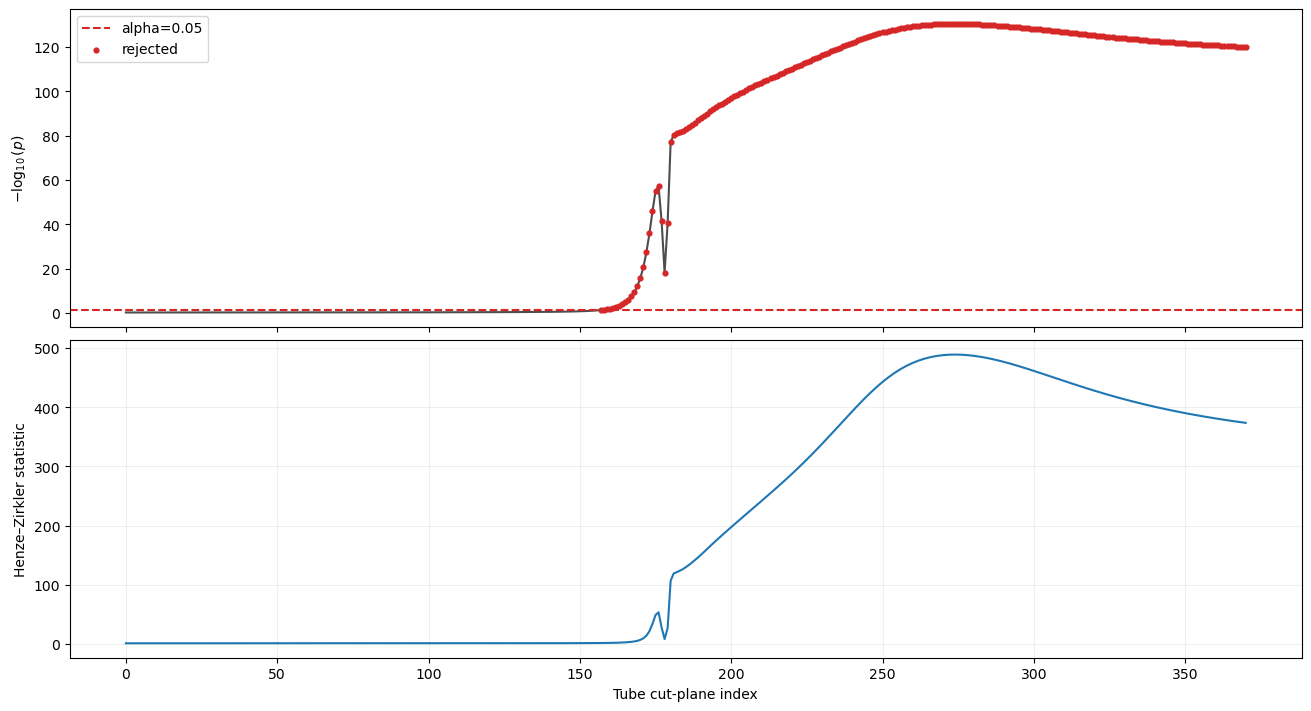

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, constrained_layout=True)
tiny = np.finfo(float).tiny
axes[0].plot(normality.cutplane_index, -np.log10(normality.p_value.clip(lower=tiny)), color='0.3')
axes[0].axhline(-np.log10(ALPHA), color='tab:red', ls='--', label=f'alpha={ALPHA}')
axes[0].scatter(non_gaussian.cutplane_index, -np.log10(non_gaussian.p_value.clip(lower=tiny)),
                s=12, color='tab:red', label='rejected', zorder=3)
axes[0].set_ylabel(r'$-\log_{10}(p)$'); axes[0].legend()
axes[1].plot(normality.cutplane_index, normality.hz, color='tab:blue')
axes[1].set(xlabel='Tube cut-plane index', ylabel='Henze–Zirkler statistic')
axes[1].grid(alpha=.2)
plt.show()

## Plot rejected point clouds against the existing ellipse

The red ring is read from the current tube JSON and projected into the same local 2D frame as the variants.

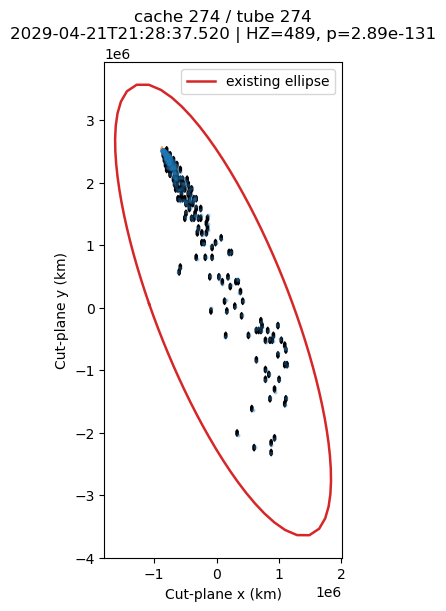

In [6]:
with TUBE_JSON.open('r', encoding='utf-8') as file:
    tube_data = json.load(file)

def existing_ring_2d(projected):
    polygon = tube_data['polygons'][projected['cutplane_index']]
    ring_3d_km = np.array([[p['x'], p['y'], p['z']] for p in polygon['points']]) / 1000.0
    # This ring was produced by the legacy normalized-coordinate pipeline and
    # is not guaranteed to lie exactly on the newly reconstructed physical plane.
    # Orthogonally project it for comparison without the legacy coplanarity warning.
    rotation = tube_util.calcRotationMatrix(projected['normal'], np.array([0.0, 0.0, 1.0]))
    centered = ring_3d_km - projected['cutplane'].center_km
    return (rotation @ centered.T).T[:, :2]

def plot_cutplane(cache_index, ax=None, density=False):
    projected = project_cache_row(int(cache_index))
    points, ring = projected['points_2d_km'], existing_ring_2d(projected)
    row = normality.iloc[int(cache_index)]
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
    if density:
        ax.hexbin(points[:, 0], points[:, 1], gridsize=55, mincnt=1, cmap='magma')
    ax.scatter(points[:, 0], points[:, 1], s=8, alpha=.38, linewidths=0)
    closed = np.vstack([ring, ring[0]])
    ax.plot(closed[:, 0], closed[:, 1], color='tab:red', lw=1.8, label='existing ellipse')
    ax.set_aspect('equal', adjustable='box')
    ax.set(xlabel='Cut-plane x (km)', ylabel='Cut-plane y (km)',
           title=f"cache {cache_index} / tube {projected['cutplane_index']}\n{row.time_utc} | HZ={row.hz:.3g}, p={row.p_value:.3g}")
    ax.legend()
    return projected

if len(non_gaussian):
    plot_cutplane(int(non_gaussian.sort_values('p_value').iloc[0].cache_index), density=True)
    plt.show()
else:
    print('No rejected cut planes at this ALPHA.')

## Gallery of strongest rejections

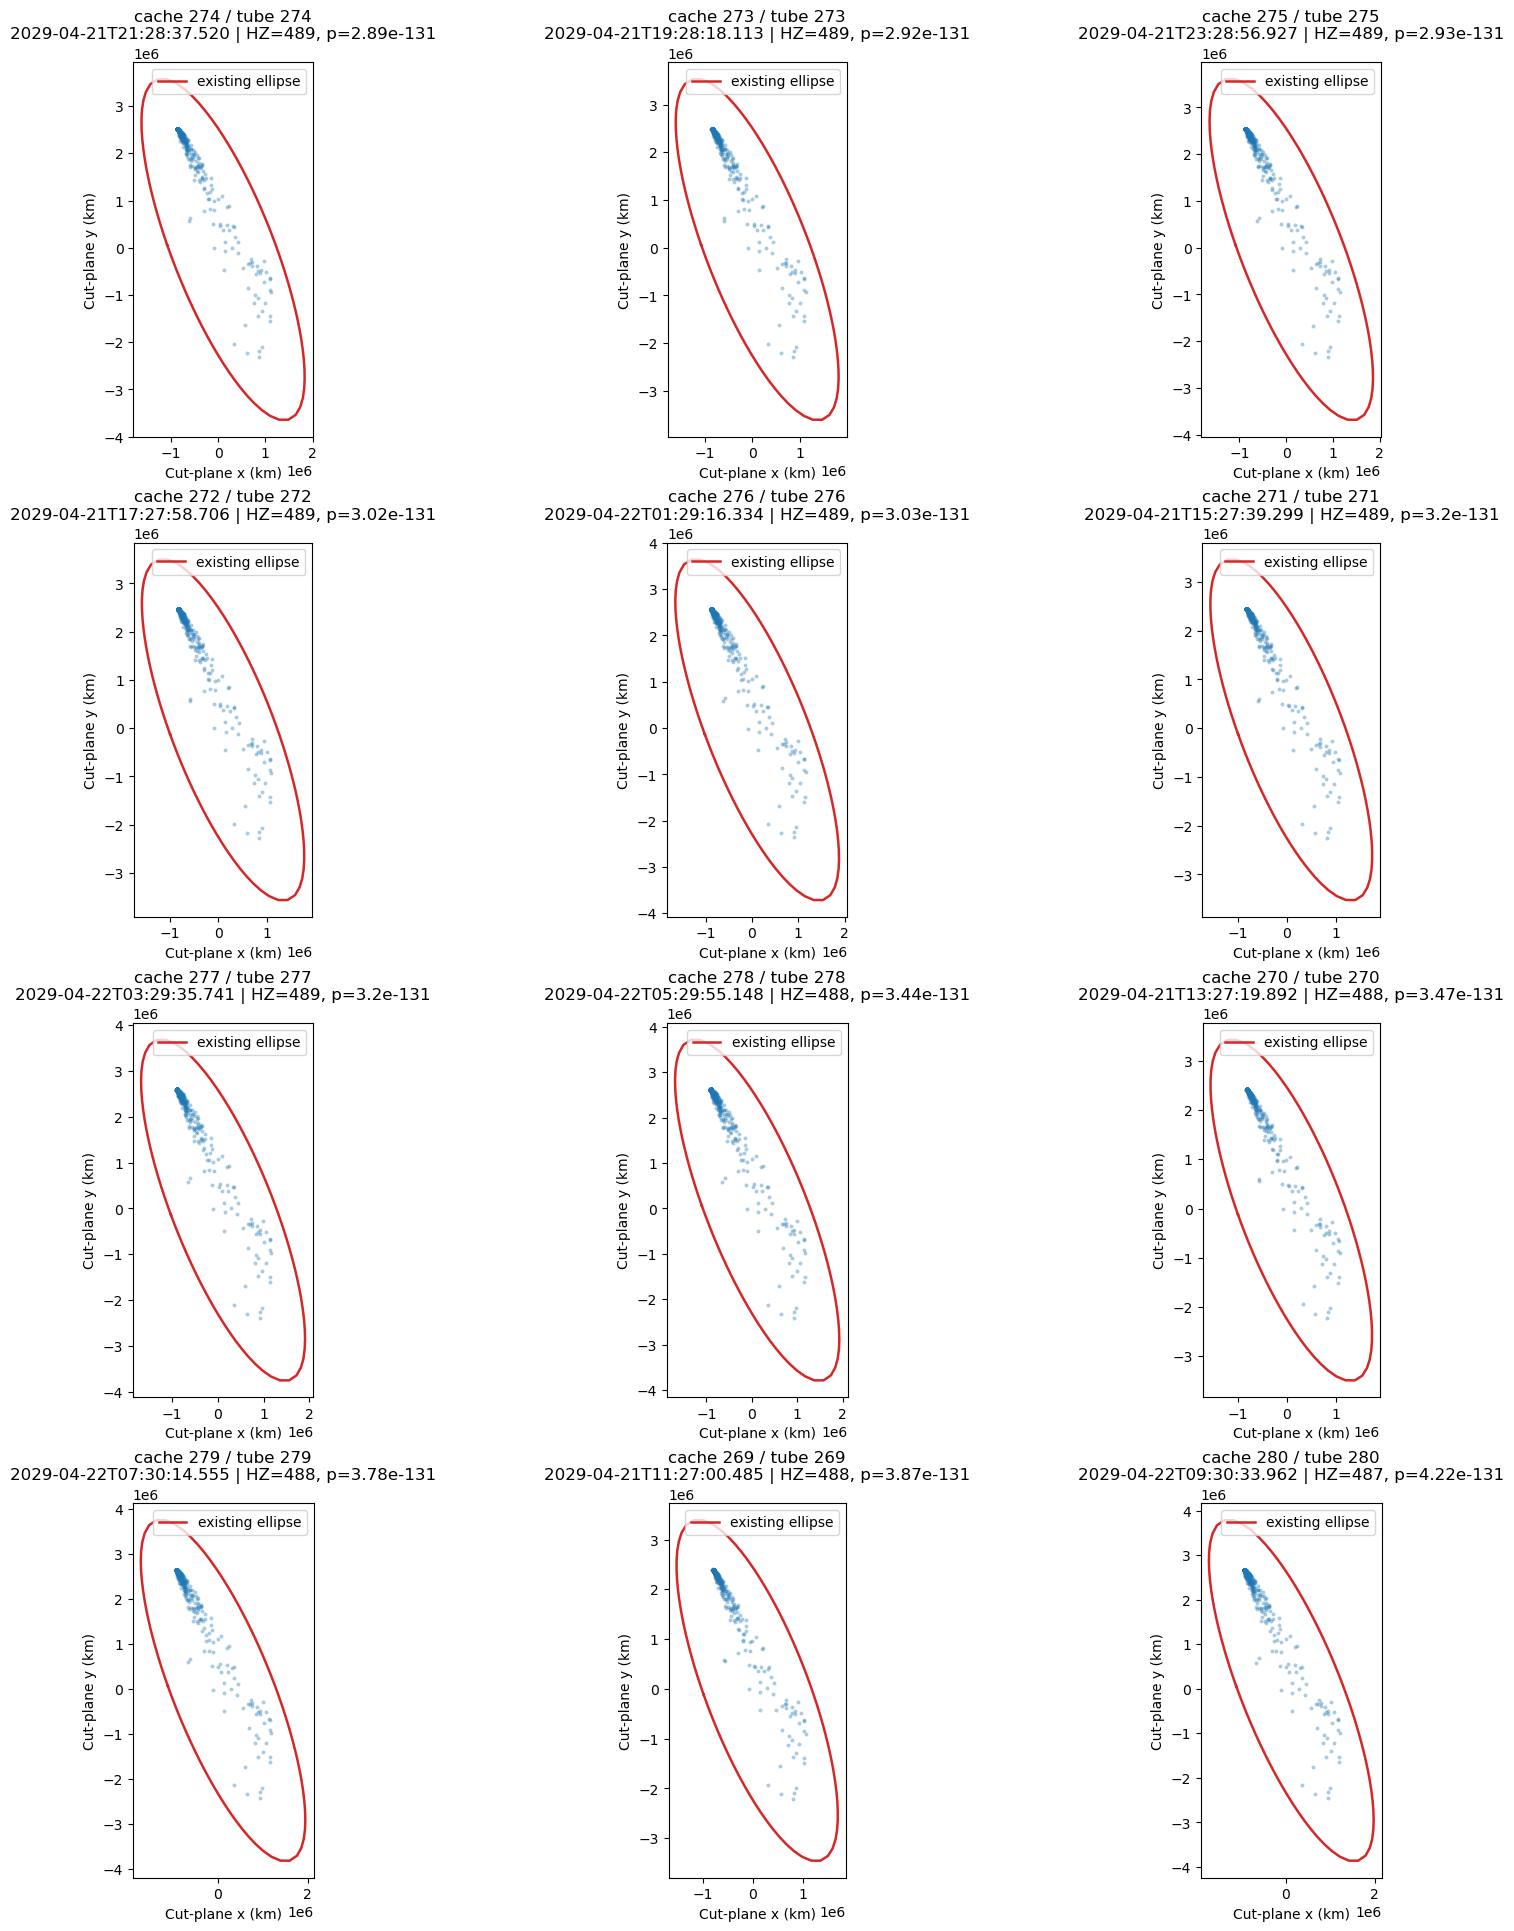

In [7]:
GALLERY_COUNT = 12
gallery = non_gaussian.sort_values('p_value').head(GALLERY_COUNT)
if len(gallery):
    cols, rows = 3, int(np.ceil(len(gallery) / 3))
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4.8*rows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, gallery.iterrows()):
        plot_cutplane(int(row.cache_index), ax=ax)
    for ax in axes[len(gallery):]: ax.set_visible(False)
    plt.show()
else:
    print('Nothing to plot.')

## Inspect one rejection and neighboring slices

Change `SELECTED_CACHE_INDEX` using the table or gallery. Neighbors show whether rejection persists or flickers for one slice.

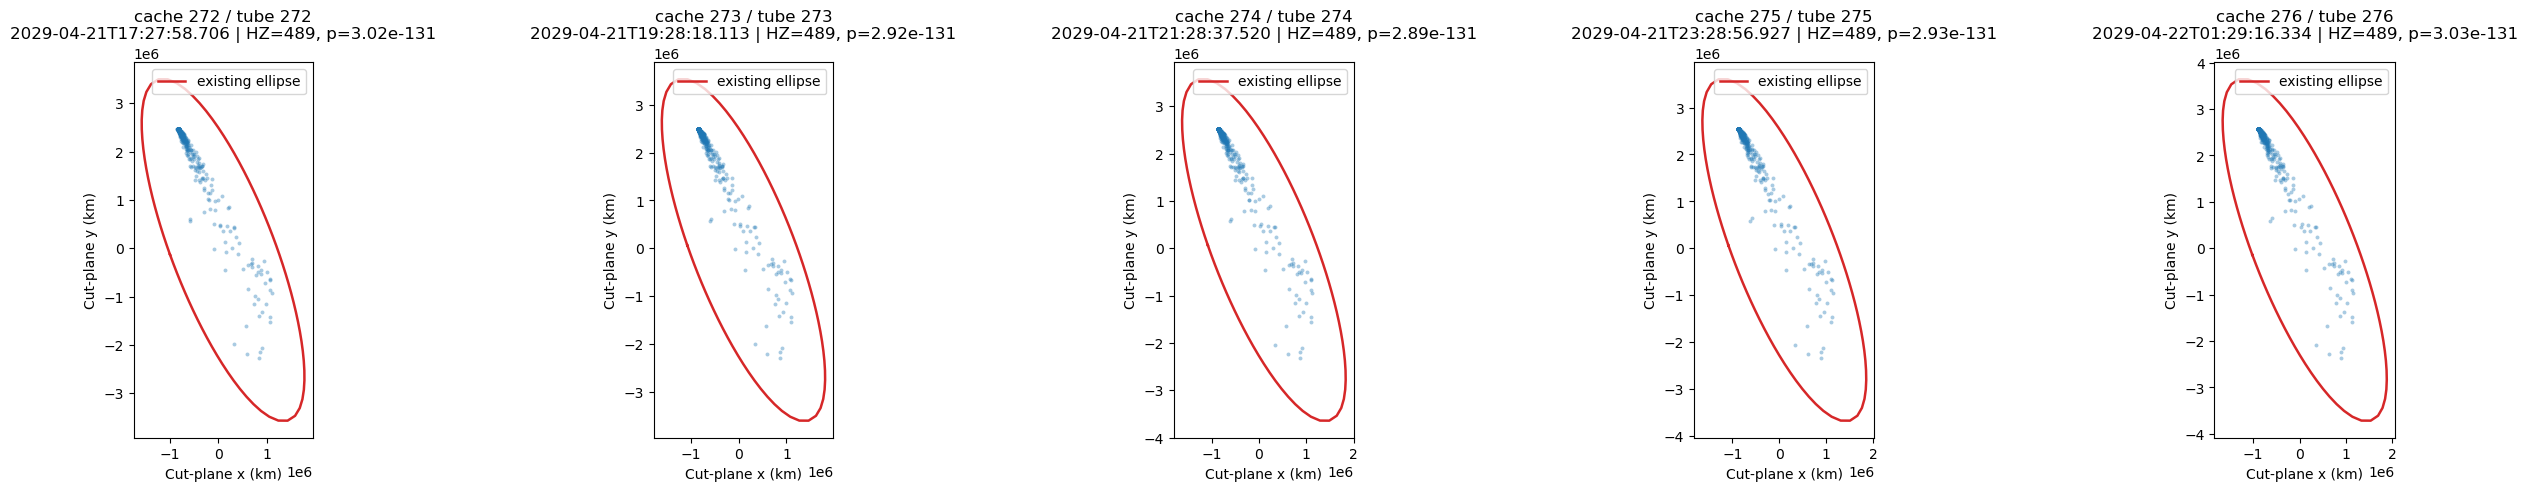

,cache_index,cutplane_index,time_utc,num_projected,hz,p_value,is_gaussian
272,272,272,2029-04-21T17:27:58.706,1000,489.158438,3.020318e-131,False
273,273,273,2029-04-21T19:28:18.113,1000,489.334852,2.922359e-131,False
274,274,274,2029-04-21T21:28:37.520,1000,489.387131,2.893950e-131,False
275,275,275,2029-04-21T23:28:56.927,1000,489.320393,2.930266e-131,False
276,276,276,2029-04-22T01:29:16.334,1000,489.139611,3.030966e-131,False


In [8]:
SELECTED_CACHE_INDEX = (int(non_gaussian.sort_values('p_value').iloc[0].cache_index)
                        if len(non_gaussian) else 0)
NEIGHBOR_RADIUS = 2
neighbors = list(range(max(0, SELECTED_CACHE_INDEX-NEIGHBOR_RADIUS),
                       min(len(normality), SELECTED_CACHE_INDEX+NEIGHBOR_RADIUS+1)))
fig, axes = plt.subplots(1, len(neighbors), figsize=(5.2*len(neighbors), 4.8), constrained_layout=True)
for ax, index in zip(np.atleast_1d(axes), neighbors):
    plot_cutplane(index, ax=ax)
plt.show()
display(normality.iloc[neighbors][['cache_index', 'cutplane_index', 'time_utc',
    'num_projected', 'hz', 'p_value', 'is_gaussian']])

## Ten consecutive alpha shapes from the first non-Gaussian cut plane

The sequence starts at the earliest rejected slice and includes the next nine chronological slices, whether or not those later slices pass the Gaussian test. Blue points are projected variants, red is the existing ellipse, and green is the alpha-shape boundary.

Starting at cache slice 180, tube cut plane 180


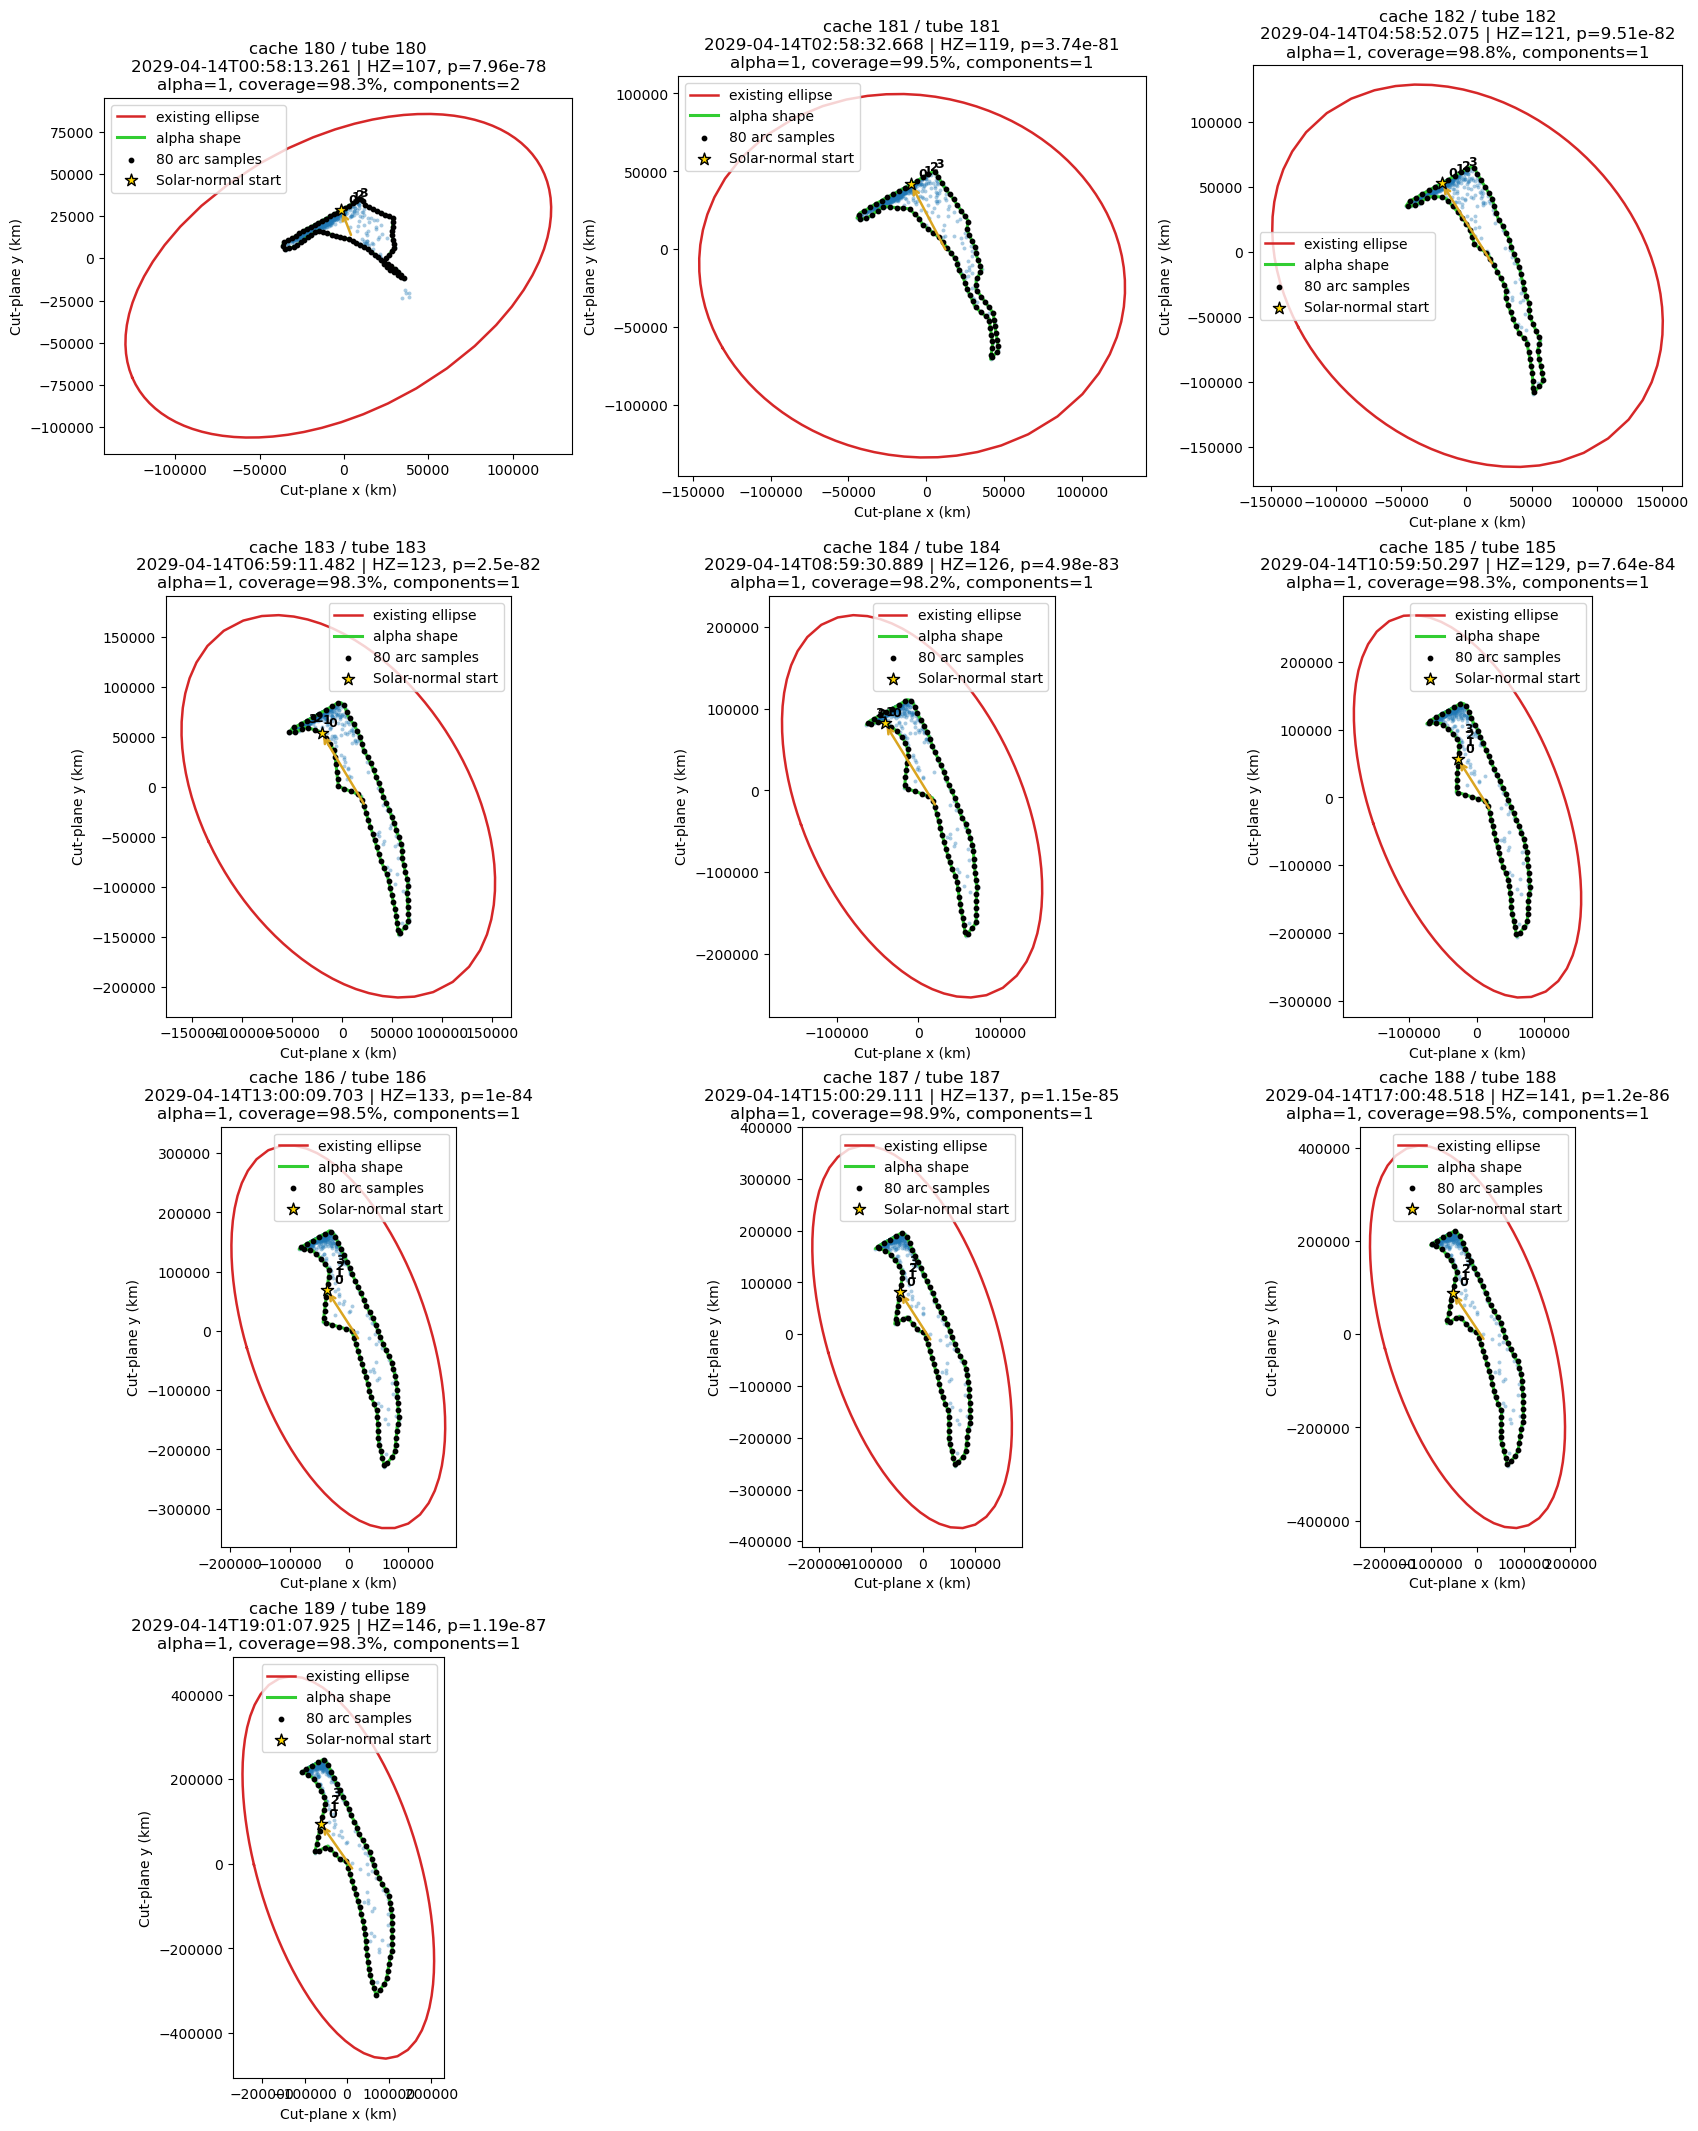

,cache_index,cutplane_index,time_utc,alpha_shape,coverage,component_count,boundary_vertices,sample_count,clockwise,convex_hull_fallback
0,180,180,2029-04-14T00:58:13.261,1.0,0.983,2,63,80,True,False
1,181,181,2029-04-14T02:58:32.668,1.0,0.995,1,67,80,True,False
2,182,182,2029-04-14T04:58:52.075,1.0,0.988,1,74,80,True,False
3,183,183,2029-04-14T06:59:11.482,1.0,0.983,1,76,80,True,False
4,184,184,2029-04-14T08:59:30.889,1.0,0.982,1,77,80,True,False
5,185,185,2029-04-14T10:59:50.297,1.0,0.983,1,73,80,True,False
6,186,186,2029-04-14T13:00:09.703,1.0,0.985,1,73,80,True,False
7,187,187,2029-04-14T15:00:29.111,1.0,0.989,1,69,80,True,False
8,188,188,2029-04-14T17:00:48.518,1.0,0.985,1,79,80,True,False
9,189,189,2029-04-14T19:01:07.925,1.0,0.983,1,78,80,True,False


In [11]:
import importlib
import tube_generation.polygon as polygon_generation
polygon_generation = importlib.reload(polygon_generation)
calculate_alpha_shape = polygon_generation.calculate_alpha_shape
sample_alpha_shape_boundary = polygon_generation.sample_alpha_shape_boundary

ALPHA_SHAPE = 1.0
NUMBER_TO_PLOT = 10
START_SLICE_INDEX = 180  # None = first non-Gaussian slice; otherwise use a cache-row index

if non_gaussian.empty:
    raise RuntimeError('No non-Gaussian cut planes are available to plot.')
first_non_gaussian_cache_index = int(
    non_gaussian.sort_values('cutplane_index').iloc[0].cache_index
)
start_index = (first_non_gaussian_cache_index
               if START_SLICE_INDEX is None else int(START_SLICE_INDEX))
if not 0 <= start_index < len(normality):
    raise IndexError(f'START_SLICE_INDEX must be between 0 and {len(normality) - 1}')
print(f'Starting at cache slice {start_index}, tube cut plane {int(cutplane_indices[start_index])}')
consecutive_indices = list(range(
    start_index,
    min(start_index + NUMBER_TO_PLOT, len(normality)),
))
selected_slices = normality.iloc[consecutive_indices]

columns = 3
rows = int(np.ceil(len(selected_slices) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(17, 5.3 * rows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()
diagnostics = []

for ax, (_, row) in zip(axes, selected_slices.iterrows()):
    cache_index = int(row.cache_index)
    projected = plot_cutplane(cache_index, ax=ax)
    result = calculate_alpha_shape(projected['points_2d_km'], alpha=ALPHA_SHAPE)
    samples = sample_alpha_shape_boundary(result, 80, projected['normal'])
    boundary = np.vstack([result.boundary_2d, result.boundary_2d[0]])
    ax.plot(boundary[:, 0], boundary[:, 1], color='limegreen', lw=2.2, label='alpha shape')
    ax.scatter(samples[:, 0], samples[:, 1], s=10, color='black', zorder=4, label='80 arc samples')
    ax.scatter(samples[0, 0], samples[0, 1], s=85, marker='*', color='gold',
               edgecolor='black', zorder=5, label='Solar-normal start')
    ring_center = samples.mean(axis=0)
    ax.annotate('', xy=samples[0], xytext=ring_center,
                arrowprops=dict(arrowstyle='->', color='goldenrod', lw=1.8), zorder=4)
    for sample_index in range(min(4, len(samples))):
        ax.annotate(str(sample_index), samples[sample_index], xytext=(5, 5),
                    textcoords='offset points', fontsize=9, fontweight='bold', zorder=6)
    ax.set_title(
        ax.get_title() + f'\nalpha={ALPHA_SHAPE:g}, coverage={result.coverage:.1%}, components={result.component_count}'
    )
    ax.legend(loc='best')
    diagnostics.append({
        'cache_index': cache_index, 'cutplane_index': int(row.cutplane_index),
        'time_utc': row.time_utc, 'alpha_shape': ALPHA_SHAPE,
        'coverage': result.coverage, 'component_count': result.component_count,
        'boundary_vertices': len(result.boundary_2d),
        'sample_count': len(samples),
        'clockwise': bool(0.5 * np.sum(samples[:, 0] * np.roll(samples[:, 1], -1)
                                    - samples[:, 1] * np.roll(samples[:, 0], -1)) < 0),
        'convex_hull_fallback': result.used_convex_hull,
    })

for ax in axes[len(selected_slices):]:
    ax.set_visible(False)
plt.show()
display(pd.DataFrame(diagnostics))

## What to look for

- Is rejection caused by skewness, curvature, multiple groups, or isolated outliers?
- Do rejected slices form continuous time intervals?
- Does the ellipse enclose large visibly empty regions?
- Are there disconnected groups that would require multiple polygons?
- Does the conclusion remain stable when `ALPHA` changes?

These observations determine whether the first polygon prototype should use a convex hull, alpha shape, density contour, or clustering.

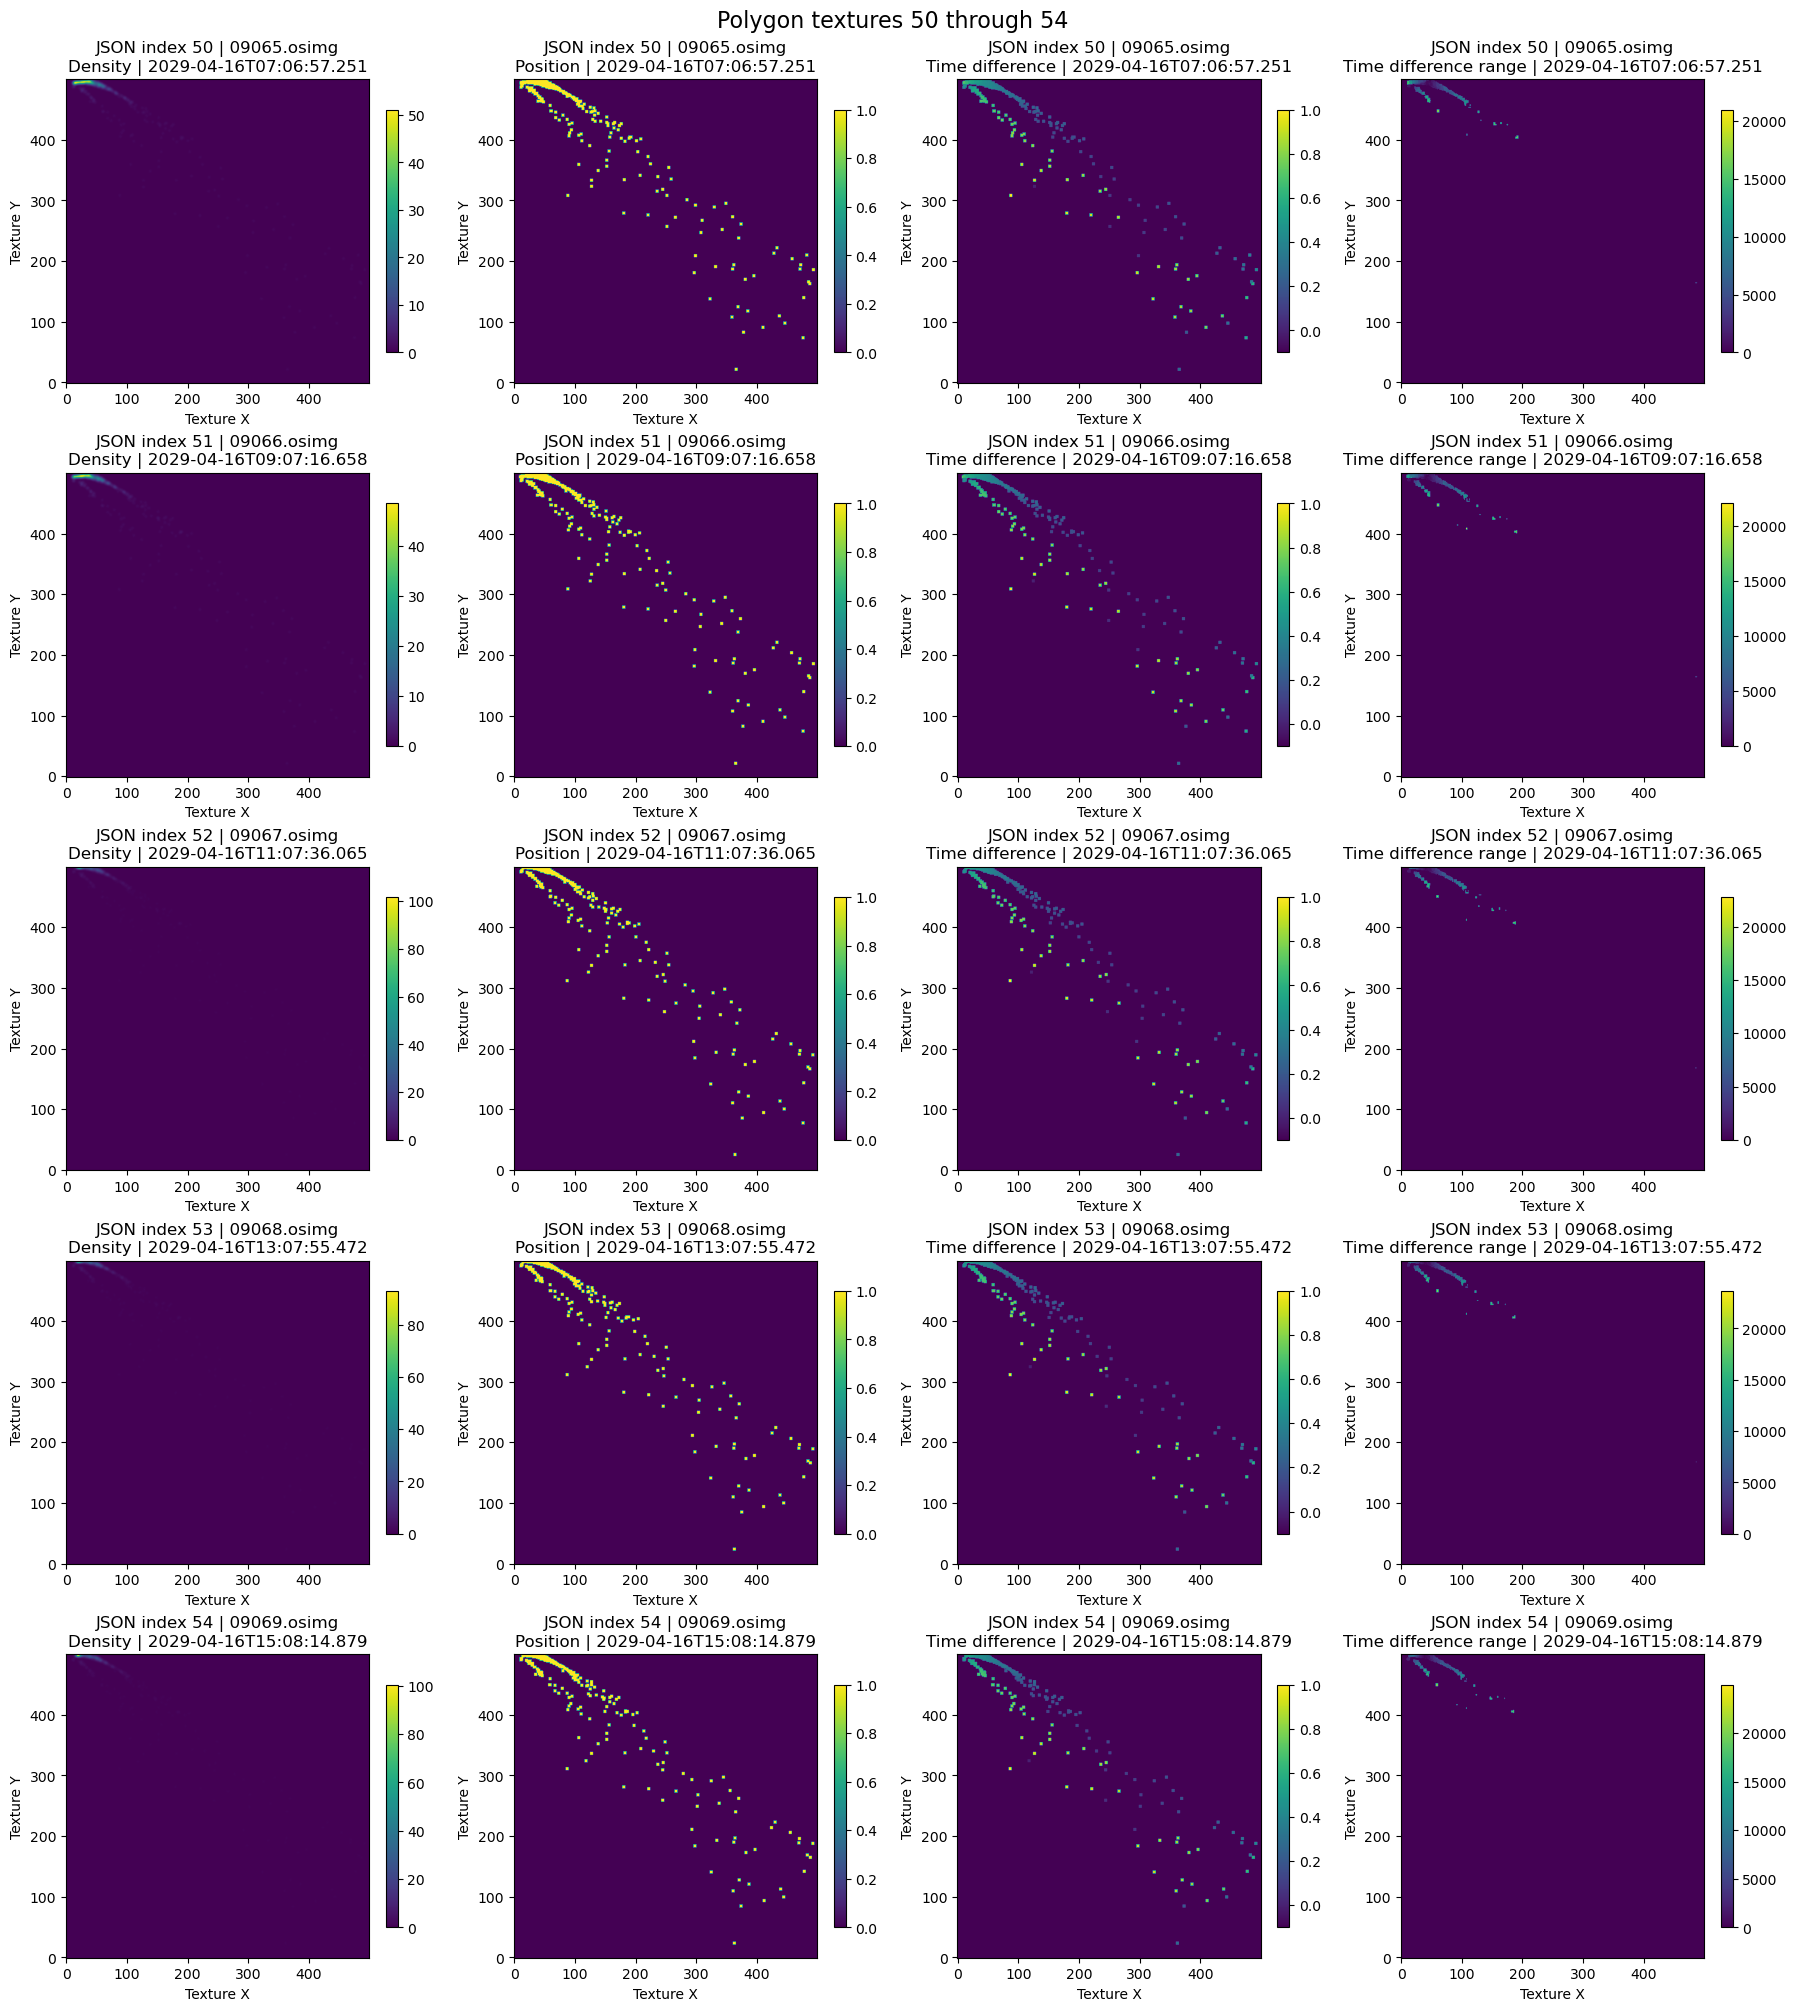

In [4]:
# Inspect five consecutive regenerated polygon textures. Change only i.
i = 50

from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np

start = Path.cwd().resolve()
repo_root = next(
    (path for path in [start, *start.parents]
     if (path / 'data' / 'B612_data' / 'Test' / '2004 MN4').is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError('Could not find the NEOviz repository root')

object_directory = repo_root / 'data' / 'B612_data' / 'Test' / '2004 MN4'
polygon_json_path = object_directory / 'tube_2004_MN4_polygon.json'
texture_directory = object_directory / 'textures_polygon'

with polygon_json_path.open('r', encoding='utf-8') as file:
    polygon_tube = json.load(file)
polygons = polygon_tube['polygons']
if not isinstance(i, int) or i < 0 or i + 5 > len(polygons):
    raise IndexError(f'i must be between 0 and {len(polygons) - 5}')

def read_osimg(path):
    with Path(path).open('rb') as file:
        version = tuple(np.fromfile(file, dtype=np.uint8, count=2))
        width, height = np.fromfile(file, dtype='<u4', count=2)
        channel_count = int(np.fromfile(file, dtype=np.uint8, count=1)[0])
        minimum_values = np.fromfile(file, dtype='<f4', count=channel_count)
        maximum_values = np.fromfile(file, dtype='<f4', count=channel_count)
        pixels = np.fromfile(file, dtype='<f4')
    expected = int(width * height * channel_count)
    if pixels.size != expected:
        raise ValueError(f'{path}: expected {expected} pixels, found {pixels.size}')
    return {
        'version': version,
        'minimum': minimum_values,
        'maximum': maximum_values,
        'pixels': pixels.reshape(int(height), int(width), channel_count),
    }

channel_names = ['Density', 'Position', 'Time difference', 'Time difference range']
fig, axes = plt.subplots(5, 4, figsize=(18, 20), constrained_layout=True)

for row, polygon_index in enumerate(range(i, i + 5)):
    polygon = polygons[polygon_index]
    texture_name = polygon['texture']
    texture = read_osimg(texture_directory / texture_name)
    if texture['pixels'].shape[2] != 4:
        raise ValueError(f'{texture_name} has {texture["pixels"].shape[2]} channels, expected 4')
    for channel, channel_name in enumerate(channel_names):
        axis = axes[row, channel]
        image = axis.imshow(texture['pixels'][:, :, channel], origin='lower', cmap='viridis')
        axis.set_title(
            f'JSON index {polygon_index} | {texture_name}\n{channel_name} | {polygon["time"]}'
        )
        axis.set_xlabel('Texture X')
        axis.set_ylabel('Texture Y')
        fig.colorbar(image, ax=axis, shrink=0.8)

fig.suptitle(f'Polygon textures {i} through {i + 4}', fontsize=16)
plt.show()
